# Modelling AXL intracellular signaling using CORNETO
In this notebook we use the advanced CARNIVAL implementation available in CORNETO to infer the intracellular signaling network from AXL to TFs to understand how AXL might be signaling inside the cardiomyocyte.

- **Parameter Sensitivity**: Alterations in solver settings, threshold values, or choice of prior-knowledge networks can materially affect the inferred network.

- **Data Dependence**: The characteristics of your dataset—experimental design, sample size, preprocessing, and normalization—will directly influence model outputs.

- **Knowledge-Base Limitations**: Underlying pathway repositories may exhibit incomplete coverage and annotation biases.

Each network generated by CARNIVAL should be regarded as a potential, simplified hypothesis of the real signalling.

## Data description
The starting point for analysis is the differentially gene expression results obtained by DESeq2. Two groups are compared: AXL vs GFP. Both groups are neonatal mouse cardiomyocytes transduced with an AAV carrying either AXL or GFP controlled by the CMV promoter. Originally, the sample numbers were n = 6 for the AXL group and n = 4. for the GFP group.


In [1]:
import gzip
import os
import shutil
import tempfile
import urllib.request
import pandas as pd

# https://decoupler-py.readthedocs.io
import decoupler as dc
import numpy as np

# https://omnipathdb.org/
import omnipath as op
import liana as li

# Pydeseq for differential expression analysis
#from pydeseq2.dds import DefaultInference, DeseqDataSet
#from pydeseq2.ds import DeseqStats

# https://corneto.org
import corneto as cn
import graphviz
#import networkx as nx

/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
max_time = 500
seeds = [i for i in range(100)] # We will run corneto 100 times with different seeds to get a distribution of solutions and select edges that appear in > 50% of runs.

In [3]:
project_dir = "/mnt/sds-hd/sd22b002/projects/ines/axl_networks"
data_dir = os.path.join(project_dir, "data")
results_dir = os.path.join(project_dir, "results")

## Load the differentially expressed genes and prepare them for enrichment analysis

In [4]:
results_df = pd.read_csv(f'{data_dir}/CMV_GFP_4_GFP_new copy.csv', index_col=0)
results_df.index.name = None
results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Gm12185,143.130786,9.575593,1.168556,8.194384,2.520000e-16,4.100000e-15
Areg,64.207984,9.497185,1.107949,8.571864,1.020000e-17,1.850000e-16
Mx1,76.262785,9.398565,1.049525,8.955069,3.400000e-19,6.970000e-18
Gad2,212.098673,9.143054,0.984750,9.284648,1.620000e-20,3.610000e-19
Batf2,25.162273,8.518925,1.096505,7.769163,7.900000e-15,1.150000e-13
...,...,...,...,...,...,...
Gm15742,1.581169,-4.984077,2.011164,-2.478205,1.320453e-02,3.621267e-02
Dlx6os1,2.141667,-5.036149,1.714296,-2.937736,3.306180e-03,1.074723e-02
Ribc2,2.209597,-5.075357,1.619974,-3.132987,1.730369e-03,6.031622e-03
Gm44763,3.589042,-5.523081,1.161145,-4.756583,1.970000e-06,1.160000e-05


In [5]:
# Translate to human for compatibilities downstream
mouse_genes = list(set(results_df.index))

# Translate to human
map_df = li.rs.get_hcop_orthologs(url='https://ftp.ebi.ac.uk/pub/databases/genenames/hcop/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                  min_evidence=3 # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                 )
map_df = map_df[map_df['mouse_symbol'].isin(mouse_genes)]

# Clean up: remove genes without an ortholog in human
map_df = map_df[map_df['human_symbol'] != '-']

# Clean up: keep unique human genes (remove all human duplicated symbols to keep 1:1 orthologs)
map_df = map_df[~map_df.duplicated(subset='human_symbol', keep=False)]

map_df

/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/liana/resource/_orthology.py:228: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,human_symbol,mouse_symbol
793,A4GALT,A4galt
795,AAAS,Aaas
796,AACS,Aacs
814,AADACL4,AAdacl4fm3
820,AADAT,Aadat
...,...,...
68071,ZXDC,Zxdc
68075,ZYG11B,Zyg11b
68077,ZYX,Zyx
68078,ZZEF1,Zzef1


In [6]:
# Check number of shared genes between results_df and map_df
shared_genes = set(results_df.index).intersection(set(map_df['mouse_symbol']))
print(f"Number of shared genes between results_df and map_df: {len(shared_genes)}")

Number of shared genes between results_df and map_df: 14376


In [7]:
results_df_human = (
    results_df
    .merge(map_df[['mouse_symbol', 'human_symbol']], left_index=True, right_on='mouse_symbol', how='inner')
    .set_index('human_symbol')
    .drop(columns='mouse_symbol')
)
results_df_human.index.name = None
results_df_human


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AREG,64.207984,9.497185,1.107949,8.571864,1.020000e-17,1.850000e-16
GAD2,212.098673,9.143054,0.984750,9.284648,1.620000e-20,3.610000e-19
BATF2,25.162273,8.518925,1.096505,7.769163,7.900000e-15,1.150000e-13
ZBP1,60.765023,8.348459,1.037019,8.050442,8.250000e-16,1.290000e-14
IFI44,108.575798,7.874472,0.825610,9.537759,1.460000e-21,3.530000e-20
...,...,...,...,...,...,...
SOX3,1.565495,-4.372016,1.662257,-2.630168,8.534268e-03,2.480964e-02
MMRN1,24.472608,-4.458015,0.512836,-8.692871,3.530000e-18,6.690000e-17
FABP12,1.823412,-4.611004,1.578598,-2.920950,3.489664e-03,1.127966e-02
SLC6A4,2.763425,-4.763750,1.516458,-3.141366,1.681620e-03,5.882150e-03


In [8]:
data = results_df_human[["stat"]].T.rename(index={"stat": "AXL.vs.GFP"})
data

,AREG,GAD2,BATF2,ZBP1,IFI44,MGARP,FGF23,TNFSF10,OAS3,OAS2,...,C4BPA,SNTG1,PRR29,NWD2,CACNG3,SOX3,MMRN1,FABP12,SLC6A4,RIBC2
AXL.vs.GFP,8.571864,9.284648,7.769163,8.050442,9.537759,11.802403,11.087488,6.730749,5.410251,5.960714,...,-1.337394,-2.277473,-1.793139,-1.443435,-1.966594,-2.630168,-8.692871,-2.92095,-3.141366,-3.132987


## Estimation of Transcription Factor activities with Deocupler and CollecTRI

In [9]:
# Retrieve CollecTRI gene regulatory network (through Omnipath).
# These are regulons that we will use for enrichment tests
# to infer TF activities
collectri = dc.op.collectri(organism="human")
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


In [10]:
# Run
tf_acts, tf_padj = dc.mt.ulm(data=data, net=collectri)

# Save results as df
tf_results = pd.DataFrame({
    'TF': tf_acts.columns,
    'activity': tf_acts.iloc[0].values,
    'padj': tf_padj.iloc[0].values,
})

tf_results.to_csv(f'{results_dir}/axl_vs_gfp_collectri_results.csv', index=False)

# Filter by sign padj
msk = (tf_padj.T < 0.05).iloc[:, 0]
tf_acts = tf_acts.loc[:, msk]

tf_acts

,AHR,AP1,ARNT,ASCL1,ATF2,ATF4,ATF6,BRCA1,CDX1,CEBPB,...,STAT3,STAT5A,STAT6,TFAP2A,TFDP3,TP53,VDR,WT1,XBP1,ZNF384
AXL.vs.GFP,3.053675,4.746311,3.224224,3.236294,4.253237,3.623217,4.18807,3.229059,2.881085,5.120162,...,3.883968,3.648714,3.312184,3.680567,-2.854236,4.539511,3.437021,3.144656,4.362368,2.830087


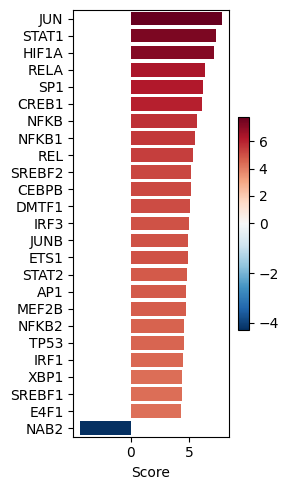

In [11]:
dc.pl.barplot(data=tf_acts, name="AXL.vs.GFP", top=25, figsize=(3, 5))

## Inferring intracellular signaling networks with CARNIVAL and CORNETO

CORNETO is a unified framework for knowledge-driven network inference. It includes a very flexible implementation of CARNIVAL that expands its original capabilities. We will see how to use it under different assumptions to extract a network from a prior knowledge network and a set of potential receptors + our estimated TFs

Installed version: v1.0.0b7
Available backends: CVXPY v1.9.2
Default backend (corneto.opt): CVXPY
Installed solvers: SCIPY
Plot backend (default): auto -> graphviz
Available plot backends: graphviz v0.14.2; networkx v3.6.1+mpl v3.10.8; graphviz-wasm
Installed path: /home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto
Repository: https://github.com/saezlab/corneto
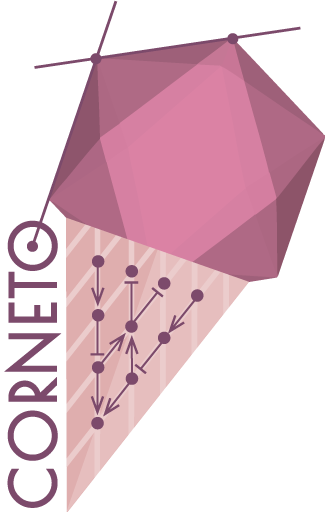

In [12]:
cn.info()

In [13]:
from corneto.methods.future import CarnivalFlow

CarnivalFlow.show_references()

- Pablo Rodriguez-Mier, Martin Garrido-Rodriguez, Attila Gabor, Julio Saez-Rodriguez. Unified knowledge-driven network inference from omics data. bioRxiv, pp. 10 (2024).
 - Anika Liu, Panuwat Trairatphisan, Enio Gjerga, Athanasios Didangelos, Jonathan Barratt, Julio Saez-Rodriguez. From expression footprints to causal pathways: contextualizing large signaling networks with CARNIVAL. NPJ systems biology and applications, Vol. 5, No. 1, pp. 40 (2019).

In [14]:
# We get only interactions from SIGNOR http://signor.uniroma2.it/
pkn = op.interactions.OmniPath.get(databases=["SIGNOR"], genesymbols=True)
pkn = pkn[pkn.consensus_direction == True]
pkn.head()

,source,target,source_genesymbol,target_genesymbol,is_directed,is_stimulation,is_inhibition,consensus_direction,consensus_stimulation,consensus_inhibition,sources,references,curation_effort,n_sources,n_primary_sources,n_references,references_stripped
0,Q13976,Q13507,PRKG1,TRPC3,True,False,True,True,False,True,PhosphoSite_MIMP;MIMP;HPRD_MIMP;PhosphoSite_no...,SIGNOR:14983059;HPRD:14983059;KEA:14983059;Pro...,7,15,8,2,14983059;16331690
1,P06241,Q9Y210,FYN,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;HPRD;SPIKE_LC,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;SP...,4,5,4,3,14761972;16713569;21471003
2,Q13976,Q9Y210,PRKG1,TRPC6,True,False,True,True,False,True,Sparser_ProtMapper;phosphoELM_MIMP;PhosphoSite...,TRIP:18617565;SIGNOR:19961855;ProtMapper:21402...,4,11,5,4,18617565;19961855;21402151;24740790
3,P12931,Q9Y210,SRC,TRPC6,True,True,False,True,True,False,TRIP;PhosphoPoint;SIGNOR;ProtMapper;HPRD;REACH...,TRIP:14761972;HPRD:14761972;SIGNOR:21471003;Pr...,4,6,5,2,14761972;21471003
4,Q13976,Q9HCX4,PRKG1,TRPC7,True,True,False,True,True,False,iPTMnet;TRIP;SIGNOR;ProtMapper;SIGNOR_ProtMapper,SIGNOR:21402151;ProtMapper:21402151;TRIP:21402151,3,5,4,1,21402151


In [15]:
pkn["interaction"] = pkn["is_stimulation"].astype(int) - pkn["is_inhibition"].astype(int)
sel_pkn = pkn[["source_genesymbol", "interaction", "target_genesymbol"]]
sel_pkn

,source_genesymbol,interaction,target_genesymbol
0,PRKG1,-1,TRPC3
1,FYN,1,TRPC6
2,PRKG1,-1,TRPC6
3,SRC,1,TRPC6
4,PRKG1,1,TRPC7
...,...,...,...
65526,LPAR5,1,GNA13
65527,PRKCA,-1,ITPKB
65528,UBXN1,1,NGLY1
65529,CCNC,-1,NOTCH1


In [16]:
# We create the CORNETO graph by importing the edges and interaction
from corneto.io import load_graph_from_sif_tuples

G = load_graph_from_sif_tuples([(r[0], r[1], r[2]) for _, r in sel_pkn.iterrows() if r[1] != 0])
G.shape

/tmp/ipykernel_1229064/1534210904.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


(6092, 63820)

In [17]:
# As measurements, we take the estimated TFs, we will filter out TFs with p-val > 0.001
significant_tfs = tf_acts[tf_padj <= 0.05].T.dropna().sort_values(by="AXL.vs.GFP", ascending=False)
significant_tfs

,AXL.vs.GFP
JUN,7.780727
STAT1,7.311096
HIF1A,7.117247
RELA,6.354864
SP1,6.227957
...,...
TFDP3,-2.854236
HIC1,-2.868902
ETV3,-2.995610
FOXO4,-3.560276


In [18]:
# We keep only the ones in the PKN graph
measurements = significant_tfs.loc[significant_tfs.index.intersection(G.V)].to_dict()["AXL.vs.GFP"]
measurements

{'JUN': 7.7807270635307795,
 'STAT1': 7.311096246465834,
 'HIF1A': 7.117246985162688,
 'RELA': 6.354863801048934,
 'SP1': 6.22795741501343,
 'CREB1': 6.078315415632176,
 'NFKB1': 5.524722877729113,
 'REL': 5.358884035260232,
 'SREBF2': 5.168100849196765,
 'CEBPB': 5.12016163124013,
 'IRF3': 4.947491120867724,
 'JUNB': 4.946335748499413,
 'ETS1': 4.942886841012515,
 'STAT2': 4.7840611751888265,
 'NFKB2': 4.589034505986096,
 'TP53': 4.539511101716554,
 'IRF1': 4.459438099962724,
 'XBP1': 4.362368077953721,
 'SREBF1': 4.348904215690747,
 'E4F1': 4.272650627952872,
 'ATF2': 4.2532369533522285,
 'ATF6': 4.188069740127439,
 'ELF3': 4.165772344741414,
 'SSRP1': 4.13488895471242,
 'SP3': 4.040564181592219,
 'ETS2': 4.001091131696821,
 'IRF9': 3.958347902915842,
 'MZF1': 3.900123024949837,
 'STAT3': 3.883968070562552,
 'NFKBIB': 3.874494734199612,
 'ELK4': 3.7959632141458592,
 'ELK1': 3.7518599056298396,
 'TFAP2A': 3.6805672764696187,
 'STAT5A': 3.6487137968492527,
 'ATF4': 3.6232168144845804,


In [19]:
# Check that AXL is in graph
"AXL" in G.V

True

In [20]:
# Here we pass the receptors. We're going to use AXL as receptor. We set it as active because the treatment is AXL activation, and AXL is overexpressed in the treatment group.
inputs = {"AXL": 1}  # 1=up, -1=down
inputs

{'AXL': 1}

In [21]:
# Create the dataset in standard format
carnival_data = dict()
for inp, v in inputs.items():
    carnival_data[inp] = dict(value=v, role="input", mapping="vertex")
for out, v in measurements.items():
    carnival_data[out] = dict(value=v, role="output", mapping="vertex")
data = cn.Data.from_cdict({"sample1": carnival_data})
data

Data(n_samples=1, n_feats=[69])

### CARNIVAL
We will use now the CARNIVAL, as implemented with CORNETO, with a penalty to regularize the solution. For hypothesis exploration, we can try different values and manually inspect the solutions. We are going to penalize also the selection of indirect rules, to simplify the solution. These rules are:
- A -> B in the PKN, and we observe B is downregulated, we explain it with downregulation of its upstream gene A
- A -| B in the PKN, and we observe B is upregulated, we explain it with downregulation of A

In [22]:
carnival = CarnivalFlow(lambda_reg=1.0, indirect_rule_penalty=10)
P = carnival.build(G, data)
P.expr

Unreachable vertices for sample: 0


{'edge_inhibits': edge_inhibits: Variable((5418, 1), edge_inhibits, boolean=True),
 '_dag_layer': _dag_layer: Variable((1303, 1), _dag_layer),
 'const0x1fb0aabfdc2763d4': const0x1fb0aabfdc2763d4: Constant(CONSTANT, NONNEGATIVE, (1303, 5418)),
 '_flow': _flow: Variable((5418,), _flow),
 'edge_activates': edge_activates: Variable((5418, 1), edge_activates, boolean=True),
 'const0x49c914861ca4b33': const0x49c914861ca4b33: Constant(CONSTANT, NONNEGATIVE, (1303, 5418)),
 'flow': _flow: Variable((5418,), _flow),
 'vertex_value': Expression(AFFINE, UNKNOWN, (1303, 1)),
 'vertex_activated': Expression(AFFINE, NONNEGATIVE, (1303, 1)),
 'vertex_inhibited': Expression(AFFINE, NONNEGATIVE, (1303, 1)),
 'edge_value': Expression(AFFINE, UNKNOWN, (5418, 1)),
 'edge_has_signal': Expression(AFFINE, NONNEGATIVE, (5418, 1)),
 'vertex_max_depth': _dag_layer: Variable((1303, 1), _dag_layer)}

In [23]:
results = {}

# We run corneto 100 times, each with a different seed. Then we will select edges that appear in > 50% of runs.
for seed in seeds:
    print(f"Running corneto with seed {seed}...")
    P.solve(solver="highs", max_seconds=60, verbosity=0, random_seed=seed);
    
    for o in P.objectives:
        print(o.name, "->", o.value)
    
    # Extract the selected edges
    sol_edges = np.flatnonzero(np.abs(P.expr.edge_value.value) > 0.5)
    carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    dot_source = carnival.processed_graph.plot_values(
        vertex_values=P.expr.vertex_value.value,
        edge_values=P.expr.edge_value.value,
        edge_indexes=sol_edges,
    )

    # inject smaller font size
    dot_source = dot_source.replace(
        'node [fixedsize="true"];',
        'node [fixedsize="true", fontsize="8"]; edge [fontsize="8"];'
    )

    # display(graphviz.Source(dot_source))

    # Extracting the solution graph
    G_sol = carnival.processed_graph.edge_subgraph(sol_edges)
    print(G_sol.shape)


    # Get node df of final filtered graph solution
    node_df = pd.DataFrame(P.expr.vertex_value.value, index=carnival.processed_graph.V, columns=["node_activity"])
    node_df_filt = node_df.loc[node_df.index.isin(G_sol.V)]
    node_df_filt = node_df_filt.reset_index(names='gene_symbol')

    # Get edge df of final filtered graph solution, reshaped to From, To, edge_activity
    edge_df = pd.DataFrame(P.expr.edge_value.value, index=carnival.processed_graph.E, columns=["edge_activity"])
    edge_df_filtered = edge_df.loc[edge_df.index.isin(G_sol.E)].reset_index()
    edge_df_filtered.columns = ["From", "To", "edge_activity"]

    # Save into dictionary
    results[seed] = {"nodes": node_df, "edges": edge_df}


Running corneto with seed 0...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 35.4487560337467
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 76.99999999999991
(77, 77)
Running corneto with seed 1...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 35.4487560337467
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 76.99999999999991
(77, 77)
Running corneto with seed 2...


...

/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 35.4487560337467
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 76.99999999999991
(77, 77)
Running corneto with seed 98...


/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


error_sample1_0 -> 35.4487560337467
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 76.99999999999991
(77, 77)
Running corneto with seed 99...
error_sample1_0 -> 35.4487560337467
penalty_indirect_rules_0 -> [0.]
regularization_edge_has_signal -> 76.99999999999991
(77, 77)


/home/hd/hd_hd/hd_kd353/miniforge3/envs/basic_sc_env/lib/python3.12/site-packages/corneto/backend/_cvxpy_backend.py:206: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.


In [24]:
n_runs = len(results)

def format_side(side):
    """Turn a tuple of node names into a clean comma-joined string, or '' if empty."""
    if not side:
        return ""
    return ",".join(side)

def get_nodes(side):
    """Flatten a tuple of node names into individual node strings."""
    return list(side) if side else []

# Long-format edge table across all runs
edge_frames = []
for seed, res in results.items():
    ed = res["edges"].copy()
    ed["seed"] = seed
    ed["edge"] = ed.index
    edge_frames.append(ed.reset_index(drop=True))

edges_long = pd.concat(edge_frames, ignore_index=True)
edges_long["present"] = edges_long["edge_activity"].abs() > 0.5

# Frequency and mean activity per edge
edge_summary = (
    edges_long.groupby("edge")
    .agg(
        frequency=("present", "mean"),
        mean_activity=("edge_activity", "mean"),
        n_present=("present", "sum"),
    )
    .reset_index()
)

# Keep only edges present in >50% of runs
results_edge_df = (
    edge_summary[edge_summary["frequency"] > 0.5]
    .sort_values("frequency", ascending=False)
    .reset_index(drop=True)
)

# Add readable From/To columns
results_edge_df["From"] = results_edge_df["edge"].apply(lambda e: format_side(e[0]))
results_edge_df["To"] = results_edge_df["edge"].apply(lambda e: format_side(e[1]))
results_edge_df = results_edge_df.drop(columns="edge")[
    ["From", "To", "frequency", "mean_activity", "n_present"]
]

# Get the set of nodes involved in these edges (flattening both sides)
involved_nodes = set()
for e in edge_summary.loc[edge_summary["frequency"] > 0.5, "edge"]:
    involved_nodes.update(get_nodes(e[0]))
    involved_nodes.update(get_nodes(e[1]))

# Long-format node table, averaged over all 100 runs
node_frames = []
for seed, res in results.items():
    nd = res["nodes"].copy()
    nd["seed"] = seed
    nd["node"] = nd.index
    node_frames.append(nd.reset_index(drop=True))

nodes_long = pd.concat(node_frames, ignore_index=True)

node_summary = (
    nodes_long.groupby("node")["node_activity"]
    .mean()
    .reset_index()
    .rename(columns={"node_activity": "mean_activity"})
)

# Filter to nodes involved in the selected edges
results_node_df = node_summary[node_summary["node"].isin(involved_nodes)].reset_index(drop=True)
results_node_df = results_node_df.rename(columns={"node": "Node"})

In [25]:
results_edge_df.to_csv(f"{results_dir}/axl_vs_gfp_corneto_edges.csv", index=False)
results_node_df.to_csv(f"{results_dir}/axl_vs_gfp_corneto_nodes.csv", index=False)

In [26]:
results_node_df

,Node,mean_activity
0,AHR,1.0
1,ATF2,1.0
2,ATF4,1.0
3,ATF6,1.0
4,AXL,1.0
...,...,...
71,TFAP2A,1.0
72,TP53,1.0
73,VDR,1.0
74,WT1,1.0


In [27]:
# Annotate node df with log2FC results from DESeq2
results_node_df = results_node_df.merge(
    results_df_human[["log2FoldChange", "padj"]],
    left_on="Node",
    right_index=True,
    how="left",
)
results_node_df = results_node_df.rename(columns={'log2FoldChange': 'deseq2.log2FC', 'padj': 'deseq2.padj', 'mean_activity': 'corneto_node_mean_activity'})

# Annotate node df with TF activity predictions from decoupler
results_node_df = results_node_df.merge(
    tf_results.rename(columns={"activity": "collectri.activity", "padj": "collectri.padj"}),
    left_on="Node",
    right_on="TF",
    how="left",
)
results_node_df = results_node_df.drop(columns="TF")
results_node_df.to_csv(f"{results_dir}/axl_vs_gfp_corneto_nodes_annotated.csv", index=False)
results_node_df

,Node,corneto_node_mean_activity,deseq2.log2FC,deseq2.padj,collectri.activity,collectri.padj
0,AHR,1.0,1.486682,5.320000e-07,3.053675,0.023509
1,ATF2,1.0,-0.177355,1.389406e-02,4.253237,0.000572
2,ATF4,1.0,0.890329,3.650000e-20,3.623217,0.004999
3,ATF6,1.0,-0.161447,3.831981e-02,4.188070,0.000736
4,AXL,1.0,6.644417,0.000000e+00,NaN,NaN
...,...,...,...,...,...,...
71,TFAP2A,1.0,-2.363305,2.303107e-01,3.680567,0.004204
72,TP53,1.0,-0.007003,9.647015e-01,4.539511,0.000199
73,VDR,1.0,2.060224,1.320000e-10,3.437021,0.008625
74,WT1,1.0,-0.131001,8.371953e-01,3.144656,0.018275


### Visualisations

In [28]:
#G = nx.DiGraph()

# Add nodes with all their attributes
#for _, row in results_node_df.iterrows():
#    G.add_node(
#        row["Node"],
#        corneto_activity=row["corneto_node_mean_activity"],
#        log2FC=row["deseq2.log2FC"],
#        deseq2_padj=row["deseq2.padj"],
#        tf_activity=row.get("tf_activity", None),
#        tf_padj=row.get("tf.padj", None),
#    )

# Add edges with their attributes
#for _, row in results_edge_df.iterrows():
#    G.add_edge(
#        row["From"],
#        row["To"],
#        frequency=row["frequency"],
#        mean_activity=row["mean_activity"],
#    )

#print(G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges")

In [29]:
#def layered_layout(G, x_gap=2.0, y_gap=1.5):
#    """
#    Assigns a hierarchical layout based on topological generations.
#    Works for DAGs (which CARNIVAL solutions are, by construction).
#    """
#    generations = list(nx.topological_generations(G))
#    
#    pos = {}
#    for depth, layer_nodes in enumerate(generations):
#        layer_nodes = sorted(layer_nodes)  # stable, readable ordering within a layer
#        n = len(layer_nodes)
#        for i, node in enumerate(layer_nodes):
#            # Center each layer horizontally
#            x = (i - (n - 1) / 2) * x_gap
#            y = -depth * y_gap  # negative so it flows top-to-bottom
#            pos[node] = (x, y)
#    return pos

#pos = layered_layout(G)

In [30]:
#print(nx.is_directed_acyclic_graph(G))

In [31]:
#import matplotlib.pyplot as plt
#import matplotlib.cm as cm
#import matplotlib.colors as mcolors

#def plot_network(G, pos, color_by, title, cmap="RdBu_r", vmin=None, vmax=None, figsize=(14, 10)):
#    values = [G.nodes[n].get(color_by, 0) or 0 for n in G.nodes]
#    if vmin is None:
#        vmax = max(abs(min(values)), abs(max(values)), 1e-6)
#        vmin = -vmax

#    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
#    node_colors = [cm.get_cmap(cmap)(norm(v)) for v in values]

#    fig, ax = plt.subplots(figsize=figsize)
#    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=12,
#                            edge_color="gray", alpha=0.5, connectionstyle="arc3,rad=0.05")
#    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
#                            node_size=700, edgecolors="black", linewidths=0.8)
#    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)

#    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
#    sm.set_array([])
#    fig.colorbar(sm, ax=ax, label=color_by, shrink=0.7)

#    ax.set_title(title)
#    ax.axis("off")
#    plt.tight_layout()
#    return fig

In [32]:
#plot_network(G, pos, color_by="log2FC", title="Signaling network colored by log2FC")
#plot_network(G, pos, color_by="tf_activity", title="Signaling network colored by TF activity")
#plot_network(G, pos, color_by="corneto_activity", title="Signaling network colored by CARNIVAL activity")

## Session info

In [ ]:
cn.__version__

'1.0.0b7'

In [34]:
dc.__version__

'2.1.6'

In [35]:
op.__version__

'1.0.12'

In [36]:
li.__version__

'1.8.0'